# Módulo 07 - Tarefa 02

#### 1) Carregue a base e garanta que a base está como deveria.

Considere a base que você ajustou na lição passada. Carregue-a. Caso ainda haja alguma pendência, ajuste - lembre-se de que o scikitlearn não recebe variáveis em formato string, somente numéricas, e não aceita '*missings*'. 

- Separe 70% da base para treinamento e 30% para validação. Cada uma dessas partes terá dois objetos, um armazenando a variável resposta ```mau```e outro armazenando as variáveis explicativas (lembrando: sem variáveis string, já com as dummies).

In [12]:
# carregando a base

import os

import pandas as pd
import numpy as np



print("Pasta atual:")
print(os.getcwd())

print("\nArquivos aqui:")
print(os.listdir())

os.getcwd()
print(os.getcwd())


df = pd.read_csv('.ipynb_checkpoints/mod07_tarefa01_base_tratada.csv')


print('Dimensão da base:')
print(df.shape)


print('\nPrimeiras linhas:')
print(df.head())

print('\nInformações gerais:')
print(df.info())

Pasta atual:
C:\Users\DELL\Documents\Hd-arquivos\cursos-e-pós\Curso-EBAC-cientista-de-Dados\EBAC-Cientista-de-dados\Curso\projetos\parte-08-Arvores I\tarefa-02

Arquivos aqui:
['.ipynb_checkpoints', 'Cientista de Dados M7 A3 - Melhor valor e variável pra quebra (1).ipynb', 'Cientista de dados_M07 - tarefa 02.zip', 'Mod 07 - Tarefa 02.ipynb', 'Pratique 2 — EBAC LMS.mp4', 'Pratique 2 — EBAC LMS.txt', 'Profissão Cientista de Dados M7 A4 (1).pdf', 'Profissão Cientista de Dados M7 A4 II.zip', 'Profissão Cientista de Dados M7 A5 II (1).zip', 'Profissão Cientista de Dados M7 A5.pdf', 'Profissão Cientista de Dados M7 A6 - Overfitting, treino e teste.ipynb', 'Profissão Cientista de Dados M7 A7 (1).pdf', 'Profissão Cientista de Dados M7 A7 - Pre pruning.ipynb', 'Profissão Cientista de Dados M7 A7.pdf', 'Profissão Cientista de Dados M7 A8.zip', 'Profissão Cientista de Dados M7 A9.pdf', 'tarefa-01-resolvendo-fazendo.ipynb']
C:\Users\DELL\Documents\Hd-arquivos\cursos-e-pós\Curso-EBAC-cientista-de-D

Resolvendo a tarefa 2 - Exercicio 1

In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

import matplotlib.pyplot as plt


# conferr se a base está pronta
print(df.info())

print('\nValores ausentes por coluna:')
print(df.isna().sum().sum())

print('\nVariável resposta:')
print(df['mau'].value_counts())

print('\nProporção da variável resposta:')
print(df['mau'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16650 entries, 0 to 16649
Data columns (total 29 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   qtd_filhos                              16650 non-null  int64  
 1   idade                                   16650 non-null  float64
 2   tempo_emprego                           16650 non-null  float64
 3   possui_celular                          16650 non-null  int64  
 4   possui_fone_comercial                   16650 non-null  int64  
 5   possui_fone                             16650 non-null  int64  
 6   possui_email                            16650 non-null  int64  
 7   qt_pessoas_residencia                   16650 non-null  float64
 8   mau                                     16650 non-null  bool   
 9   sexo_M                                  16650 non-null  bool   
 10  posse_de_veiculo_Y                      16650 non-null  bo

In [23]:
# separando x e y

# Separação treino e teste (70/30)

from sklearn.model_selection import train_test_split

X = df.drop('mau', axis=1)
y = df['mau']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=100,
    stratify=y
)

print('===== SPLIT DOS DADOS =====')

print(f'Observações treino: {X_train.shape[0]}')
print(f'Observações teste: {X_test.shape[0]}')

print(f'\nNúmero de variáveis (features): {X_train.shape[1]}')

print('\n===== DISTRIBUIÇÃO DA TARGET (TREINO) =====')
print(y_train.value_counts())

print('\nProporção:')
print(y_train.value_counts(normalize=True))

print('\n===== DISTRIBUIÇÃO DA TARGET (TESTE) =====')
print(y_test.value_counts())

print('\nProporção:')
print(y_test.value_counts(normalize=True))


===== SPLIT DOS DADOS =====
Observações treino: 11655
Observações teste: 4995

Número de variáveis (features): 28

===== DISTRIBUIÇÃO DA TARGET (TREINO) =====
mau
False    11382
True       273
Name: count, dtype: int64

Proporção:
mau
False    0.976577
True     0.023423
Name: proportion, dtype: float64

===== DISTRIBUIÇÃO DA TARGET (TESTE) =====
mau
False    4878
True      117
Name: count, dtype: int64

Proporção:
mau
False    0.976577
True     0.023423
Name: proportion, dtype: float64


In [24]:
# Conferencia mais analitica

print('===== CONFERÊNCIA FINAL DO SPLIT =====')

print('\nDimensão X_train:', X_train.shape)
print('Dimensão X_test:', X_test.shape)

print('\nDimensão y_train:', y_train.shape)
print('Dimensão y_test:', y_test.shape)

print('\nPercentual treino:',
      round((X_train.shape[0]/df.shape[0])*100,2),'%')

print('Percentual teste:',
      round((X_test.shape[0]/df.shape[0])*100,2),'%')

print('\n===== CHECK STRATIFY =====')

print('\nTarget total:')
print(y.value_counts(normalize=True))

print('\nTarget treino:')
print(y_train.value_counts(normalize=True))

print('\nTarget teste:')
print(y_test.value_counts(normalize=True))

===== CONFERÊNCIA FINAL DO SPLIT =====

Dimensão X_train: (11655, 28)
Dimensão X_test: (4995, 28)

Dimensão y_train: (11655,)
Dimensão y_test: (4995,)

Percentual treino: 70.0 %
Percentual teste: 30.0 %

===== CHECK STRATIFY =====

Target total:
mau
False    0.976577
True     0.023423
Name: proportion, dtype: float64

Target treino:
mau
False    0.976577
True     0.023423
Name: proportion, dtype: float64

Target teste:
mau
False    0.976577
True     0.023423
Name: proportion, dtype: float64


#### 2) Vamos para o modelo:

1. Defina um objeto com a função da árvore de decisão vista em aula.
2. Treine o modelo com os dados que você separou para treinamento.
3. Visualize a árvore. Talvez você queira aumentar um pouco a figura.
4. Produza uma visualização da matriz de classificação (ou matriz de confusão) - coloque os rótulos como "aprovados" e "reprovados" - pois afinal de contas, são essas as decisões que se podem tomar com propostas de crédito.
5. Calcule a acurácia na base de treinamento

Resolvendo tarefa 2 - arvores I - exercicio 2 - item 1
Defina um objeto com a função da árvore de decisão vista em aula.

In [25]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=100)

print('===== MODELO CRIADO =====')
print(clf)
print('\nObjeto da árvore de decisão criado com sucesso.')

===== MODELO CRIADO =====
DecisionTreeClassifier(random_state=100)

Objeto da árvore de decisão criado com sucesso.


REsolvendo - tarefa 2 - arvores I - exercicio 2 - item 2
Treine o modelo com os dados que você separou para treinamento.

In [26]:
clf.fit(X_train, y_train)

print('===== MODELO TREINADO =====')
print('O modelo foi treinado com sucesso com os dados de treino.')

print('\nNúmero de amostras usadas no treino:', X_train.shape[0])
print('Número de variáveis usadas no treino:', X_train.shape[1])

===== MODELO TREINADO =====
O modelo foi treinado com sucesso com os dados de treino.

Número de amostras usadas no treino: 11655
Número de variáveis usadas no treino: 28


REsolvendo - tarefa 2 - arvores I - exercicio 2 - item 3
Visualize a árvore. Talvez você queira aumentar um pouco a figura.

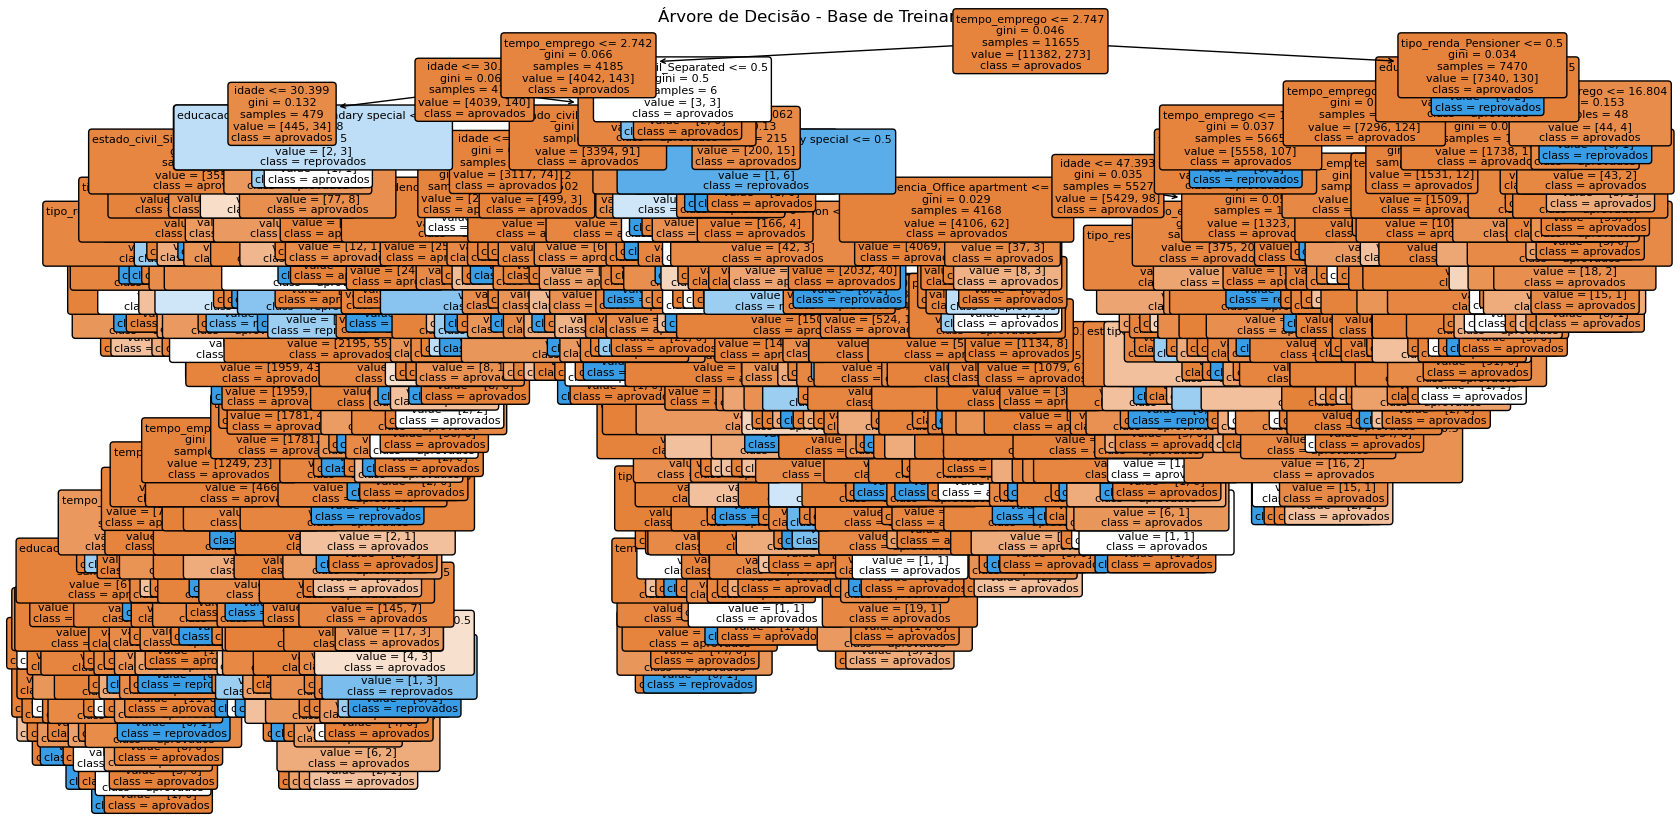

===== ÁRVORE PLOTADA =====
Visualização gerada com sucesso
Profundidade da árvore: 31
Número de folhas: 443


In [28]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    clf,
    feature_names=X.columns.tolist(),   # CORREÇÃO AQUI
    class_names=['aprovados','reprovados'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title('Árvore de Decisão - Base de Treinamento')
plt.show()

print('===== ÁRVORE PLOTADA =====')
print('Visualização gerada com sucesso')
print('Profundidade da árvore:', clf.get_depth())
print('Número de folhas:', clf.get_n_leaves())


REsolvendo - tarefa 2 - arvores I - exercicio 2 - item 4
Produza uma visualização da matriz de classificação (ou matriz de confusão) - coloque os rótulos como "aprovados" e "reprovados" - pois afinal de contas, são essas as decisões que se podem tomar com propostas de crédito.

===== MATRIZ DE CLASSIFICAÇÃO =====

Matriz numérica:
[[11367    15]
 [   86   187]]


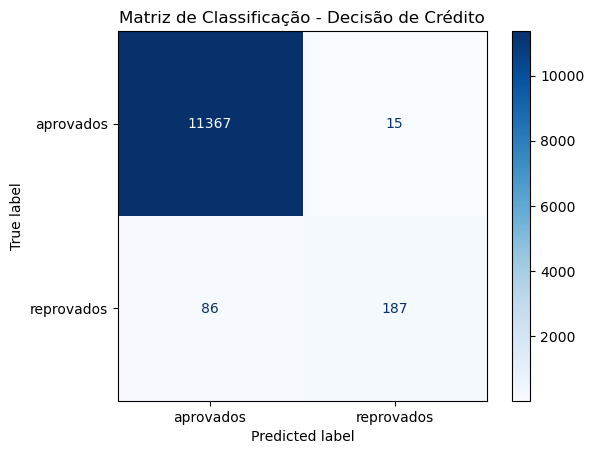


Visualização criada com sucesso.
A matriz mostra as decisões de crédito simuladas pelo modelo.


In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Fazendo previsões no treino
y_pred_train = clf.predict(X_train)

print("===== MATRIZ DE CLASSIFICAÇÃO =====")

# Criando a matriz
cm_train = confusion_matrix(y_train, y_pred_train)

print("\nMatriz numérica:")
print(cm_train)

# Visualização gráfica com rótulos pedidos no exercício
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_train,
    display_labels=['aprovados','reprovados']
)

disp.plot(cmap='Blues')

plt.title("Matriz de Classificação - Decisão de Crédito")

plt.show()

print("\nVisualização criada com sucesso.")
print("A matriz mostra as decisões de crédito simuladas pelo modelo.")

REsolvendo - tarefa 2 - arvores I - exercicio 2 - item 5
Calcule a acurácia na base de treinamento

In [31]:
from sklearn.metrics import accuracy_score

# Calculando acurácia
acc_train = accuracy_score(y_train, y_pred_train)

print("===== ACURÁCIA DO MODELO =====")

print("\nAcurácia na base de treinamento:", round(acc_train,4))

# Contagem de acertos e erros
acertos = (y_train == y_pred_train).sum()

erros = (y_train != y_pred_train).sum()

print("\nTotal de acertos:", acertos)

print("Total de erros:", erros)

print("Total de observações:", len(y_train))

# Taxa de erro
erro = 1 - acc_train

print("\nTaxa de erro:", round(erro,4))

print("\nCálculo concluído com sucesso.")

===== ACURÁCIA DO MODELO =====

Acurácia na base de treinamento: 0.9913

Total de acertos: 11554
Total de erros: 101
Total de observações: 11655

Taxa de erro: 0.0087

Cálculo concluído com sucesso.


#### 3) Vamos avaliar o modelo na base de testes

1. Classifique a base de teste de acordo com a árvore que você treinou no item 2.
2. Produza a visualização da matriz de confusão para a base de teste.
3. Calcule a acurácia da base de teste. Compare com a acurácia da base de treinamento.
4. Treine uma nova árvore com número mínimo de observações por folha de 5 e máximo de profundidade de 10. Use o random_state = 123. Avalie a matriz de classificação. Observe a distribuição da predição - qual a proporção de proponentes foram classificados como 'maus'?
5. Como ficaria a acurácia se você classificasse todos os contratos como 'bons'?

In [ ]:
REsolvendo - tarefa 2 - arvores I - exercicio 3 - item 1
3.1 Classifique a base de teste de acordo com a árvore que você treinou no item 2.

In [32]:
# Classificando a base de teste treinada

y_pred_test = clf.predict(X_test)

print("===== CLASSIFICAÇÃO DA BASE DE TESTE =====")

print("\nPrimeiras 10 previsões:")
print(y_pred_test[:10])

print("\nPrimeiros 10 valores reais:")
print(y_test.iloc[:10].values)

print("\nQuantidade total de previsões geradas:", len(y_pred_test))

print("\nClassificação da base de teste concluída com sucesso.")

===== CLASSIFICAÇÃO DA BASE DE TESTE =====

Primeiras 10 previsões:
[False False False False False False False False False False]

Primeiros 10 valores reais:
[False False False False False False False False False False]

Quantidade total de previsões geradas: 4995

Classificação da base de teste concluída com sucesso.


REsolvendo - tarefa 2 - arvores I - exercicio 3 - item 2
Produza a visualização da matriz de confusão para a base de teste.

===== MATRIZ DE CONFUSÃO - TESTE =====

Matriz numérica:
[[4812   66]
 [  86   31]]


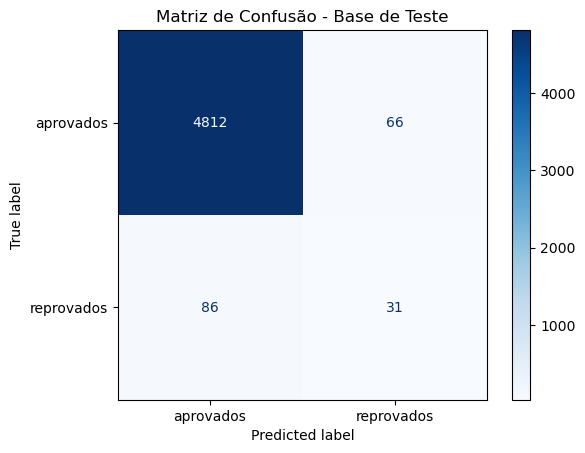


Visualização da matriz de confusão da base de teste gerada com sucesso.


In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_test = confusion_matrix(y_test, y_pred_test)

print("===== MATRIZ DE CONFUSÃO - TESTE =====")

print("\nMatriz numérica:")
print(cm_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=['aprovados', 'reprovados']
)

disp.plot(cmap='Blues')
plt.title("Matriz de Confusão - Base de Teste")
plt.show()

print("\nVisualização da matriz de confusão da base de teste gerada com sucesso.")

REsolvendo - tarefa 2 - arvores I - exercicio 3 - item 3
Calcule a acurácia da base de teste. Compare com a acurácia da base de treinamento.

In [34]:
from sklearn.metrics import accuracy_score

acc_test = accuracy_score(y_test, y_pred_test)

print("===== ACURÁCIA NA BASE DE TESTE =====")

print("\nAcurácia no teste:", round(acc_test, 4))
print("Acurácia no treino:", round(acc_train, 4))

diferenca = acc_train - acc_test

print("\nDiferença entre treino e teste:", round(diferenca, 4))

acertos_test = (y_test == y_pred_test).sum()
erros_test = (y_test != y_pred_test).sum()

print("\nTotal de acertos no teste:", acertos_test)
print("Total de erros no teste:", erros_test)
print("Total de observações no teste:", len(y_test))

if diferenca > 0.05:
    print("\nHá indício de overfitting: o modelo foi melhor no treino do que no teste.")
else:
    print("\nO modelo apresentou comportamento mais equilibrado entre treino e teste.")

===== ACURÁCIA NA BASE DE TESTE =====

Acurácia no teste: 0.9696
Acurácia no treino: 0.9913

Diferença entre treino e teste: 0.0218

Total de acertos no teste: 4843
Total de erros no teste: 152
Total de observações no teste: 4995

O modelo apresentou comportamento mais equilibrado entre treino e teste.


REsolvendo - tarefa 2 - arvores I - exercicio 3 - item 4
Treine uma nova árvore com número mínimo de observações por folha de 5 e 
máximo de profundidade de 10. Use o random_state = 123. Avalie a matriz de classificação. 

===== NOVA ÁRVORE TREINADA =====
DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=123)

Profundidade da nova árvore: 10
Número de folhas da nova árvore: 119

Primeiras 10 previsões da nova árvore:
[False False False False False False False False False False]

===== MATRIZ DE CONFUSÃO - NOVA ÁRVORE =====
[[4856   22]
 [ 110    7]]


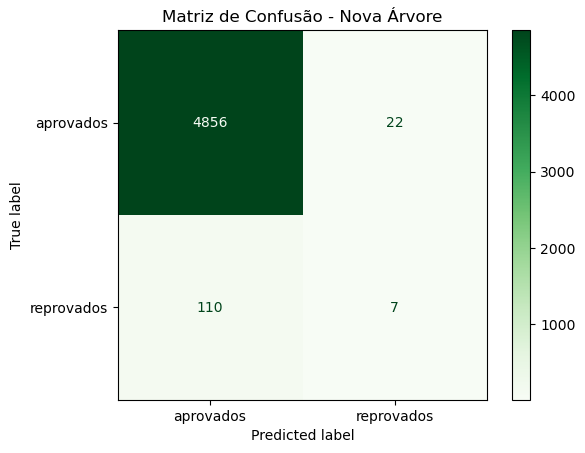


Matriz da nova árvore gerada com sucesso.


In [35]:
from sklearn.tree import DecisionTreeClassifier

# Nova árvore com poda
clf2 = DecisionTreeClassifier(
    random_state=123,
    min_samples_leaf=5,
    max_depth=10
)

clf2.fit(X_train, y_train)

print("===== NOVA ÁRVORE TREINADA =====")
print(clf2)

print("\nProfundidade da nova árvore:", clf2.get_depth())
print("Número de folhas da nova árvore:", clf2.get_n_leaves())

# Previsão no teste com a nova árvore
y_pred_test_2 = clf2.predict(X_test)

print("\nPrimeiras 10 previsões da nova árvore:")
print(y_pred_test_2[:10])

# Matriz de confusão da nova árvore
cm_test_2 = confusion_matrix(y_test, y_pred_test_2)

print("\n===== MATRIZ DE CONFUSÃO - NOVA ÁRVORE =====")
print(cm_test_2)

disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_test_2,
    display_labels=['aprovados', 'reprovados']
)

disp2.plot(cmap='Greens')
plt.title("Matriz de Confusão - Nova Árvore")
plt.show()

print("\nMatriz da nova árvore gerada com sucesso.")

In [ ]:
REsolvendo - tarefa 2 - arvores I - exercicio 3 - item 5
Observe a distribuição da predição - qual a proporção de proponentes foram classificados como 'maus'?

In [37]:
print("===== DISTRIBUIÇÃO DAS PREVISÕES - NOVA ÁRVORE =====")

dist_pred = pd.Series(y_pred_test_2).value_counts(normalize=True)

print("\nProporção das classes previstas:")
print(dist_pred)

prop_maus = pd.Series(y_pred_test_2).mean()

print("\nProporção de proponentes classificados como 'maus':", round(prop_maus, 4))
print("Percentual de proponentes classificados como 'maus':", round(prop_maus * 100, 2), "%")

===== DISTRIBUIÇÃO DAS PREVISÕES - NOVA ÁRVORE =====

Proporção das classes previstas:
False    0.994194
True     0.005806
Name: proportion, dtype: float64

Proporção de proponentes classificados como 'maus': 0.0058
Percentual de proponentes classificados como 'maus': 0.58 %


REsolvendo - tarefa 2 - arvores I - exercicio 3 - item 6
Como ficaria a acurácia se você classificasse todos os contratos como 'bons'?

In [39]:
print("===== ACURÁCIA SE TODOS FOSSEM CLASSIFICADOS COMO BONS =====")

# Criando previsão ingênua: todo mundo como bom pagador (False)
y_pred_bom = np.zeros(len(y_test), dtype=bool)

acc_bom = accuracy_score(y_test, y_pred_bom)

print("\nAcurácia classificando todos como 'bons':", round(acc_bom, 4))
print("Percentual:", round(acc_bom * 100, 2), "%")

print("\nDistribuição real da base de teste:")
print(y_test.value_counts(normalize=True))

===== ACURÁCIA SE TODOS FOSSEM CLASSIFICADOS COMO BONS =====

Acurácia classificando todos como 'bons': 0.9766
Percentual: 97.66 %

Distribuição real da base de teste:
mau
False    0.976577
True     0.023423
Name: proportion, dtype: float64
